# Project 1 will analyze airline arrival and delay data

This analysis compares arrival delays between Alaska Airlines and AM West across five West Coast destinations: Los Angeles, Phoenix, San Diego, San Francisco, and Seattle. Using this data I will attempt to identify most/least reliable routes, analyze flight volume vs delay rate relationship using a scatter plot,

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from pandas import DataFrame, Series 



# load the airline delay data from a CSV file containing:
Airline, City, Number of on time arrivals, Number of delayed arrivals

In [4]:
#load flight data
df = pd.read_csv("project1.csv")

# I will use Pandas to perform statistical operations on the csv data to learn the total time, perform arethmatic operations to learn the delay rate and on_time rate

In [7]:
#calculate metrics
df['total'] = df.ontime + df.delayed
df['delay_rate'] = (df.delayed / df.total * 100).round(2)
df['on_time_rate'] = (df.ontime / df.total * 100).round(2)
print("Data loaded and metrics calculated:")
print(df)

Data loaded and metrics calculated:
   Airline           City  ontime  delayed  total  delay_rate  on_time_rate
0   ALASKA    Los Angeles     497       62    559       11.09         88.91
1   ALASKA        Phoenix     221       12    233        5.15         94.85
2   ALASKA      San Diego     212       20    232        8.62         91.38
3   ALASKA  San Francisco     503      102    605       16.86         83.14
4   ALASKA        Seattle    1841      305   2146       14.21         85.79
5  AM West    Los Angeles     694      117    811       14.43         85.57
6  AM West        Phoenix    4840      415   5255        7.90         92.10
7  AM West      San Diego     383       65    448       14.51         85.49
8  AM West  San Francisco     320      129    449       28.73         71.27
9  AM West        Seattle     201       61    262       23.28         76.72


## Statistical Analysis

Using pandas statistical methods (mean, median, std) to compare airline performance.

In [13]:
print("STATISTICAL ANALYSIS")

# Mean delay rate by airline
print("\n Mean Delay Rate by Airline:")
airline_stats = df.groupby('Airline')['delay_rate'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(airline_stats)

# Overall comparison
alaska_mean = df[df['Airline'] == 'ALASKA']['delay_rate'].mean()
am_west_mean = df[df['Airline'] == 'AM West']['delay_rate'].mean()

print(f"\n Alaska Average Delay Rate: {alaska_mean:.2f}%")
print(f" AM West Average Delay Rate: {am_west_mean:.2f}%")
print(f" Difference: {abs(alaska_mean - am_west_mean):.2f}%")

if alaska_mean < am_west_mean:
    print(f" Winner: ALASKA (by {am_west_mean - alaska_mean:.2f}%)")
else:
    print(f" Winner: AM West (by {alaska_mean - am_west_mean:.2f}%)")

STATISTICAL ANALYSIS

 Mean Delay Rate by Airline:
          mean  median   std   min    max
Airline                                  
ALASKA   11.19   11.09  4.59  5.15  16.86
AM West  17.77   14.51  8.21  7.90  28.73

 Alaska Average Delay Rate: 11.19%
 AM West Average Delay Rate: 17.77%
 Difference: 6.58%
 Winner: ALASKA (by 6.58%)


## Route-Level Analysis
With this newly calculated data we will use it to learn the best and worst airline routes
Identifying best and worst routes using idxmin and idxmax.


In [11]:
print("ROUTE ANALYSIS")

# Best route overall
best = df.loc[df['delay_rate'].idxmin()]
print(f"\n MOST RELIABLE ROUTE:")
print(f"   {best['Airline']} to {best['City']}")
print(f"   Delay Rate: {best['delay_rate']:.2f}%")
print(f"   Total Flights: {best['total']:,}")

# Worst route overall
worst = df.loc[df['delay_rate'].idxmax()]
print(f"\n LEAST RELIABLE ROUTE:")
print(f"   {worst['Airline']} to {worst['City']}")
print(f"   Delay Rate: {worst['delay_rate']:.2f}%")
print(f"   Total Flights: {worst['total']:,}")

ROUTE ANALYSIS

 MOST RELIABLE ROUTE:
   ALASKA to Phoenix
   Delay Rate: 5.15%
   Total Flights: 233

 LEAST RELIABLE ROUTE:
   AM West to San Francisco
   Delay Rate: 28.73%
   Total Flights: 449


## Visualization: Flight Volume vs Delay Rate

Now we will visualize this in a scatter plot to visualize the amount of flights and its relation to the rate of delays by location

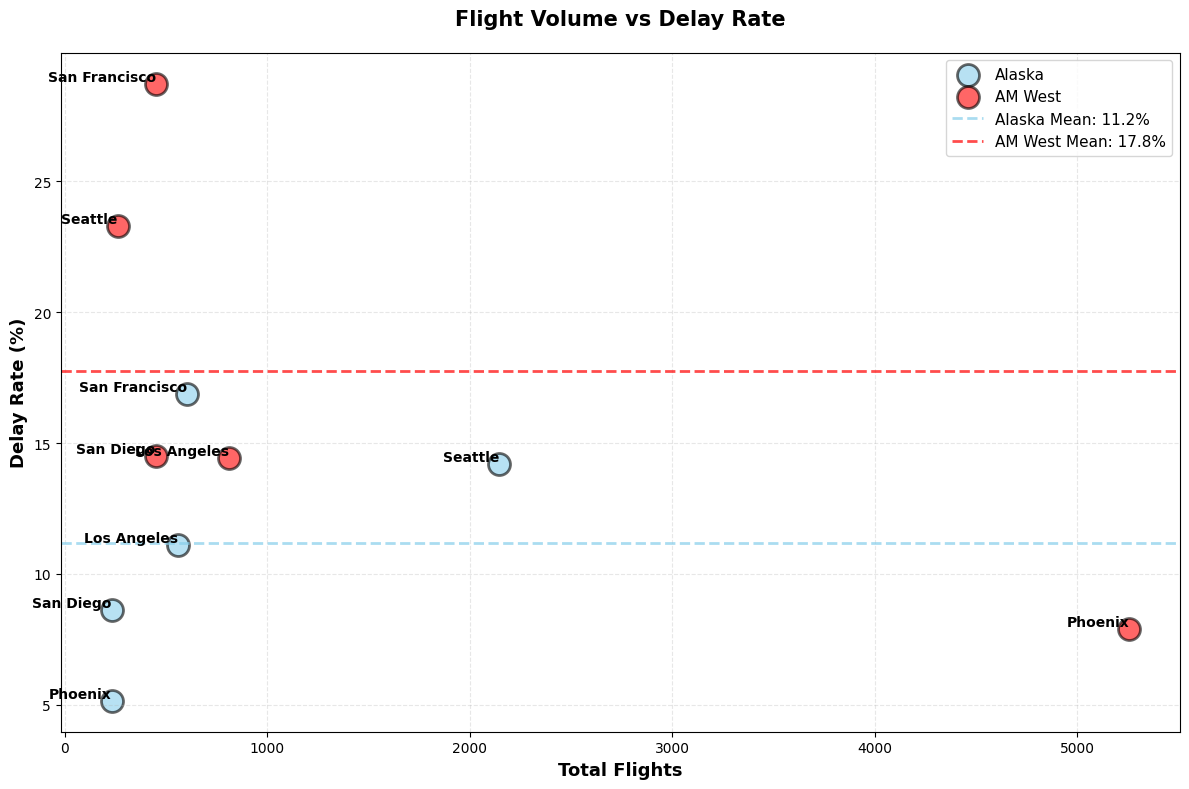

In [17]:
# Scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

alaska = df[df['Airline'] == 'ALASKA']
am_west = df[df['Airline'] == 'AM West']

ax.scatter(alaska['total'], alaska['delay_rate'], 
          s=250, alpha=0.6, color='skyblue', 
          label='Alaska', edgecolors='black', linewidth=2)
ax.scatter(am_west['total'], am_west['delay_rate'], 
          s=250, alpha=0.6, color='red', 
          label='AM West', edgecolors='black', linewidth=2)

# Add city labels
for idx, row in df.iterrows():
    ax.annotate(row['City'], 
               (row['total'], row['delay_rate']),
               fontsize=10, ha='right', va='bottom', fontweight='bold')

# Add mean lines
ax.axhline(y=alaska_mean, color='skyblue', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Alaska Mean: {alaska_mean:.1f}%')
ax.axhline(y=am_west_mean, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'AM West Mean: {am_west_mean:.1f}%')

ax.set_xlabel('Total Flights', fontsize=13, fontweight='bold')
ax.set_ylabel('Delay Rate (%)', fontsize=13, fontweight='bold')
ax.set_title('Flight Volume vs Delay Rate', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Conclusion
-------------
Alaska Airlines has better performance with an **11.19% average delay rate** compared to AM West's **17.77%** - a significant **6.58 percentage point advantage**.
--------------
Alaska Airlines to Phoenix is the most reliable flight with the lowest delay rate as shown by the scatter plot
--------------
Am West Airlines to San Francisco is the least reliable with the highst delay rate as shown by the scatter plot
--------------


